# Wikiquote Toy Language Model
Scrape quotes from a single Wikiquote page, tokenize them, and train a small next-word LSTM as a toy language model.

## Setup

In [2]:
import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup
import re
import pickle
import spacy
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

2026-09-14 16:20:44.790230: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1789402844.996023      40 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1789402845.050418      40 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Config

In [3]:
# --- Scraping config ---
URL = "https://it.wikiquote.org/wiki/Amore"

HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/129.0.0.0 Safari/537.36"
}

IGNORE = ["Indice", "Note", "Voci correlate", "Altri progetti", "Bibliografia"]
PATTERNS = [r"\[.+?\]", r"\(.+?\)"]
TO_REMOVE = {'/wiki/%25s', 'Wikipedia', 'Wikinotizie', 'Commons', 'Altri progetti'}

# --- Model config ---
SEQUENCE_LENGTH = 15
EMBED_DIM = 32
HIDDEN_UNITS = 64
EPOCHS = 350
BATCH_SIZE = 32

## Text Generation Utilities
Defined early since they only depend on a trained `model` and fitted `tokenizer`, which get created later in the notebook.

In [4]:
def sample(logits, temperature=1.0):
    """
    Sample an index from a logits array using temperature scaling.
    Assumes `logits` are raw, unnormalized model outputs (no softmax applied).
    """
    logits = np.asarray(logits).astype("float64")
    logits = logits / temperature
    exp_preds = np.exp(logits - np.max(logits))  # subtract max for numerical stability
    probs = exp_preds / np.sum(exp_preds)
    return np.random.choice(len(probs), p=probs)


def generate_text(seed_text, model, tokenizer, sequence_length=SEQUENCE_LENGTH, next_words=25, temperature=0.2):
    seed_text = seed_text.lower()
    result = seed_text.split()

    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([result[-sequence_length:]])[0]
        token_list = np.array(token_list).reshape(1, -1)

        preds = model.predict(token_list, verbose=0)[0]
        predicted_id = sample(preds, temperature)

        result.append(tokenizer.index_word.get(predicted_id, '<OOV>'))

    return ' '.join(result)

## Scraping
A single function that fetches a Wikiquote page and returns its cleaned quotes. Kept in sync with the multipage scraper's per-page logic.

In [5]:
def scrape_quotes(url, headers, ignore=IGNORE, patterns=PATTERNS, to_remove=TO_REMOVE):
    """Fetch a Wikiquote page and return (title, cleaned_quotes)."""
    response = requests.get(url, headers=headers)
    response.raise_for_status()
    soup = BeautifulSoup(response.text, "html.parser")

    title = soup.title.string
    quotes = []

    # --- Extract quotes from <p> ---
    for p in soup.find_all("p"):
        text = p.get_text(separator=" ", strip=True)

        # Skip ignored or small-tag paragraphs
        if p.find("small") or text in ignore:
            continue

        # Skip paragraphs starting with "Etichetta:"
        if text.startswith("Etichetta:"):
            continue

        # Check if paragraph starts with "Citazioni su..."
        if re.match(r"^Citazioni su.+?", text):
            ul = p.find_next("ul")
            if ul:
                for li in ul.find_all("li"):
                    quotes.append(li.get_text(separator=" ", strip=True))
            continue  # Skip adding the "Citazioni su..." paragraph itself

        # Otherwise, add the normal paragraph text
        quotes.append(text)

    # --- Extract quotes from <h3> blocks ---
    for h3 in soup.find_all("h3"):
        if h3.get_text() not in ignore:
            if h3.i:
                quotes.append(h3.i.get_text())

            ul = h3.find_next("ul")
            next_h3 = h3.find_next("h3")
            next_h2 = h3.find_next("h2")

            if next_h3 and next_h2:
                if ul != next_h3.find_next("ul") and ul != next_h2.find_next("ul"):
                    for li in ul.find_all("li"):
                        quotes.append(li.get_text())
            elif next_h3 and not next_h2:
                if ul != next_h3.find_next("ul"):
                    for li in ul.find_all("li"):
                        quotes.append(li.get_text())
            elif not next_h3 and next_h2:
                if ul != next_h2.find_next("ul"):
                    for li in ul.find_all("li"):
                        quotes.append(li.get_text())
            elif not next_h3 and not next_h2:
                for li in ul.find_all("li"):
                    quotes.append(li.get_text())

    # --- Extract quotes from <h2> blocks ---
    for h2 in soup.find_all("h2"):
        if h2.get_text() not in ignore:
            ul = h2.find_next("ul")
            next_h3 = h2.find_next("h3")
            next_h2 = h2.find_next("h2")

            if next_h3 and next_h2:
                if ul != next_h3.find_next("ul") and ul != next_h2.find_next("ul"):
                    for li in ul.find_all("li"):
                        quotes.append(li.get_text())
            elif next_h3 and not next_h2:
                if ul != next_h3.find_next("ul"):
                    for li in ul.find_all("li"):
                        quotes.append(li.get_text())
            elif not next_h3 and next_h2:
                if ul != next_h2.find_next("ul"):
                    for li in ul.find_all("li"):
                        quotes.append(li.get_text())
            elif not next_h3 and not next_h2:
                for li in ul.find_all("li"):
                    quotes.append(li.get_text())

    # --- Clean up quotes ---
    cleaned_quotes = []
    for q in quotes:
        new_q = q
        for pattern in patterns:
            new_q = re.sub(pattern, "", new_q)
        new_q = new_q.strip()
        if new_q and new_q not in to_remove:
            cleaned_quotes.append(new_q)

    return title, cleaned_quotes

In [6]:
title, cleaned_quotes = scrape_quotes(URL, HEADERS)
print(title)
cleaned_quotes

Amore - Wikiquote


['A coloro che ci spingono ad amare gli altri, suggerisco di riflettere che forse perfino amare se stessi è meno frequente di quanto comunemente si creda.',
 "A nessuna creatura può piacere di essere desiderata per l'amore di un'altra. Ognuno vuole essere amato per sé stesso.",
 "A una certa altezza dell'amore, si vedono cadere gli orpelli del romanzesco e del petrarchismo, e rimangono soltanto, nudi e violenti, lo stimolo fisico e la verità dei corpi.",
 "A volte penso che l'amore eterno sia il Babbo Natale degli adulti... sappiamo tutti che non esiste ma nessuno vuole sentirselo dire...",
 "Agire sotto l'impulso del desiderio è paura e schiavitù; spinti dall'amore, è libertà.",
 "Ah! come io conosco bene l'amore. Egli | inclina sempre a trovar de' difetti nell'oggetto | amato: tu trovi il tuo troppo orgoglioso; io | trovai il mio troppo modesto .",
 "Ahi crudo Amor, ch'ugualmente n'ancide | l'assenzio e 'l mèl che tu fra noi dispensi, | e d'ogni tempo egualmente mortali | vengon da t

## Preprocessing / Tokenization

In [7]:
nlp = spacy.load("it_core_news_sm")

text = " ".join(cleaned_quotes).lower()
doc = nlp(text)

tokens = [token.text for token in doc]
print("Tokens:", tokens)
print(len(tokens))

Tokens: ['a', 'coloro', 'che', 'ci', 'spingono', 'ad', 'amare', 'gli', 'altri', ',', 'suggerisco', 'di', 'riflettere', 'che', 'forse', 'perfino', 'amare', 'se', 'stessi', 'è', 'meno', 'frequente', 'di', 'quanto', 'comunemente', 'si', 'creda', '.', 'a', 'nessuna', 'creatura', 'può', 'piacere', 'di', 'essere', 'desiderata', 'per', "l'", 'amore', 'di', "un'", 'altra', '.', 'ognuno', 'vuole', 'essere', 'amato', 'per', 'sé', 'stesso', '.', 'a', 'una', 'certa', 'altezza', "dell'", 'amore', ',', 'si', 'vedono', 'cadere', 'gli', 'orpelli', 'del', 'romanzesco', 'e', 'del', 'petrarchismo', ',', 'e', 'rimangono', 'soltanto', ',', 'nudi', 'e', 'violenti', ',', 'lo', 'stimolo', 'fisico', 'e', 'la', 'verità', 'dei', 'corpi', '.', 'a', 'volte', 'penso', 'che', "l'", 'amore', 'eterno', 'sia', 'il', 'babbo', 'natale', 'degli', 'adulti', '...', 'sappiamo', 'tutti', 'che', 'non', 'esiste', 'ma', 'nessuno', 'vuole', 'sentirselo', 'dire', '...', 'agire', 'sotto', "l'", 'impulso', 'del', 'desiderio', 'è', '

In [8]:
tokenizer = Tokenizer(filters='', lower=False, oov_token='<OOV>')
tokenizer.fit_on_texts(tokens)

vocab_size = len(tokenizer.word_index) + 1  # +1 for padding/OOV
print("Vocabulary size:", vocab_size)

token_ids = tokenizer.texts_to_sequences([tokens])[0]
print("Token IDs:", token_ids[:20])

Vocabulary size: 5050
Token IDs: [16, 276, 7, 50, 1636, 126, 33, 46, 122, 2, 1637, 10, 1638, 7, 170, 939, 33, 24, 234, 5]


## Model

### Training windows

In [9]:
X = []
y = []

# Create training windows and target word for each window
for i in range(SEQUENCE_LENGTH, len(token_ids)):
    X.append(token_ids[i-SEQUENCE_LENGTH:i])
    y.append(token_ids[i])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (47297, 15)
y shape: (47297,)


### Build & train

In [10]:
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=EMBED_DIM, input_length=SEQUENCE_LENGTH),
    LSTM(HIDDEN_UNITS),
    Dense(vocab_size)  # predict next word
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1789402865.351925      40 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.fit(X, y, epochs=EPOCHS, batch_size=BATCH_SIZE)

Epoch 1/350


I0000 00:00:1789402869.003386     122 cuda_dnn.cc:529] Loaded cuDNN version 90300


1479/1479 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.0523 - loss: 6.5762
Epoch 2/350
1479/1479 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.0890 - loss: 5.8386
Epoch 3/350
1479/1479 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.1200 - loss: 5.5049
Epoch 4/350
1479/1479 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.1476 - loss: 5.1991
Epoch 5/350
1479/1479 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.1697 - loss: 4.9279
Epoch 6/350
1479/1479 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.1845 - loss: 4.6466
Epoch 7/350
1479/1479 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.2007 - loss: 4.3934
Epoch 8/350
1479/1479 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.2179 - loss: 4.1716
Epoch 9/350
1479/1479 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.2419 - loss: 3.9354
Epoch 10/350
1479/1479 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.2711 - loss: 3.7029
Epoch 11/350
1479/1479 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.2945 - loss: 3.5086
Epoch 12/350
1479/1479 ━━━━━━━

## Sampling
Uses the `generate_text` function defined above.

In [12]:
seed = "L'amore è"
print(generate_text(seed, model, tokenizer))

l'amore è sebbene immenso , fa morire puoi pensare a cercare l' opposto . amor sì illumina , ho imparato che ti potrebbe chiamare , come sarebbe


## Embedding Visualization

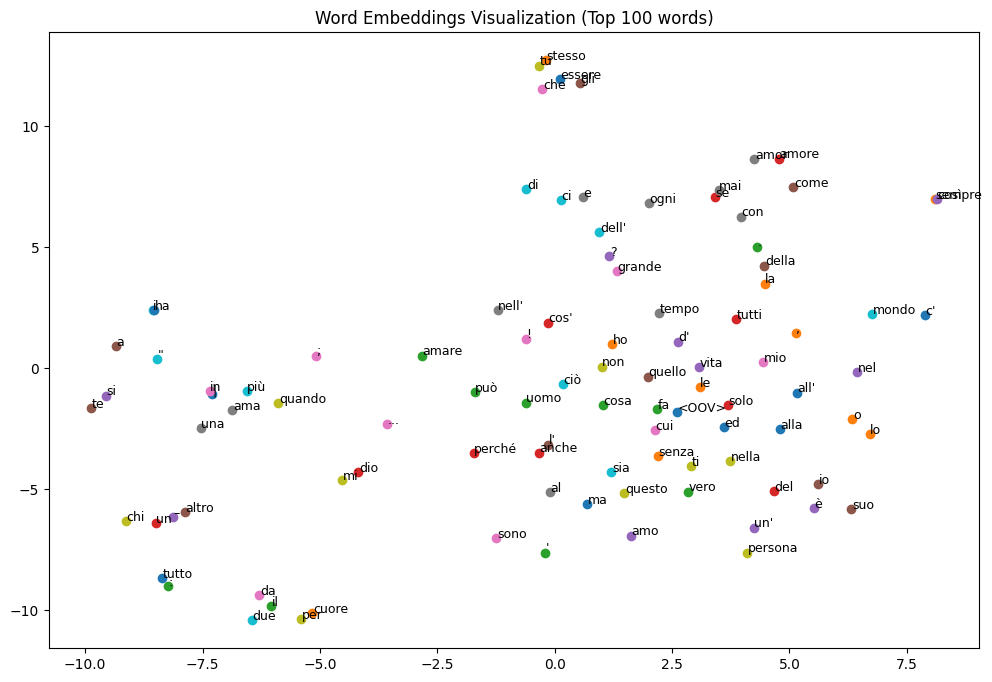

In [13]:
def plot_word_embeddings(model, tokenizer, top_n=100):
    """
    Plot word embeddings from a Keras embedding layer using t-SNE.

    Args:
        model: Trained Keras model with Embedding as first layer
        tokenizer: Fitted Keras Tokenizer
        top_n: Number of top words to plot (based on tokenizer.word_index)
    """
    embedding_weights = model.layers[0].get_weights()[0]  # shape: (vocab_size, embed_dim)

    vocab_size = min(top_n, embedding_weights.shape[0])
    embeddings_subset = embedding_weights[:vocab_size]

    tsne = TSNE(n_components=2, random_state=42, perplexity=15)
    embeddings_2d = tsne.fit_transform(embeddings_subset)

    plt.figure(figsize=(12, 8))
    for i in range(vocab_size):
        plt.scatter(embeddings_2d[i, 0], embeddings_2d[i, 1])
        plt.text(embeddings_2d[i, 0]+0.01, embeddings_2d[i, 1]+0.01,
                 tokenizer.index_word.get(i+1, ''), fontsize=9)

    plt.title(f"Word Embeddings Visualization (Top {vocab_size} words)")
    plt.show()


plot_word_embeddings(model, tokenizer, top_n=100)